# Threshold Optimisation for RobustModelMaker

This notebook uses **`ThresholdOptimizer`** (`tools/threshold_optimizer.py`) to find the
optimal `stability_threshold` for each of the three scientific datasets used in the companion
benchmark (`benchmarks/Benchmark_Suite.ipynb`).

## What the optimizer does

For each candidate threshold value the optimizer runs a complete **RobustModelMaker nested-CV**
fit and records three objectives simultaneously:

| Objective | Direction | What it measures |
|---|---|---|
| **Predictive score** | higher is better | Mean outer-fold AUC (classification) or neg-RMSE (regression) |
| **Jaccard stability** | higher is better | Consistency of selected feature sets across outer folds |
| **Compression** | higher is better | Fraction of features removed (1 minus selected / total) |

All three objectives are normalised to \[0, 1\] within the evaluated grid and combined into a
weighted composite score (equal weights by default).  The threshold with the highest composite
is **recommended**; the full **Pareto-non-dominated front** is also reported so you can choose
a different trade-off if your priorities differ.

## Why optimise the threshold?

`stability_threshold` controls how often a feature must appear across bootstrap resamples to pass
selection.  The library default (0.70) is a reasonable starting point, but different datasets have
different noise levels, feature correlation structures, and signal densities.  The threshold found
here for each dataset is what was used to fix `stability_threshold = 0.75` in the companion
benchmark — the value that scored highest in the equal-weight composite across all three datasets.

## Why a random split (not the benchmark adversarial split)?

The companion benchmark uses BenchMake's **adversarial archetypal split**, where train and test
partitions are maximally separated in feature space.  That split is designed to *stress-test
robustness* under worst-case conditions — the right tool for proving a method holds up.

Threshold optimisation is a different question: *"what threshold works best for typical training
data?"*  Optimising on an adversarially-constructed training partition can inflate noise in
bootstrap feature selection, pushing the composite objective toward a threshold that is calibrated
for worst-case data rather than representative data.  A user applying the recommended threshold
to their own dataset (with a normal split) could end up with a sub-optimal setting.

**All three datasets therefore use a plain random 80/20 split** (`random_state=42`, stratified
for classification tasks).  The held-out test set is never touched during threshold selection.

## Datasets

| Dataset | N | Features | Task | Data access |
|---|---|---|---|---|
| SECOM Manufacturing | 1 567 | 590 | Binary classification (pass/fail) | Auto-downloaded from UCI |
| Urban Land Cover | 675 | 147 | 9-class multiclass | Auto-downloaded from UCI |
| Graphene Oxide Bulk | ~1 617 | ~309 | Regression (formation energy, eV) | Local CSV — see section 3 |

> **Runtime note:** Each threshold evaluation is one full nested-CV fit.  With the default
> settings (outer\_cv=10, n\_bootstrap=25) SECOM takes roughly 10–15 minutes per threshold on
> a single core.  The **Configuration** section below offers a fast quick-scan mode suitable
> for initial exploration.

---
## 1 · Setup

This notebook is **self-contained** — it does not depend on `benchmark_suite.py` or any
other benchmark infrastructure.  The only things it needs are:

* **`RobustModelMaker.py`** — must be one level above `tools/` (standard repo layout),
  or set `ROBUST_MODEL_MAKER_PATH=/path/to/RobustModelMaker.py` in your environment.
* **`Graphene_Oxide_Bulk.csv`** — must be in `tools/` (see Section 5).
  Download from: <https://doi.org/10.25919/5e30b45f9852c>
* Internet access for SECOM and Urban Land Cover (auto-downloaded from UCI).

`ThresholdOptimizer` handles locating RobustModelMaker automatically when imported.
Edit `REPO_ROOT` below only if your directory layout differs from the standard repo structure.

```
RobustModelMaker/
├── RobustModelMaker.py
└── tools/
    ├── threshold_optimizer.py
    ├── Threshold_Optimisation.ipynb   ← this notebook
    └── Graphene_Oxide_Bulk.csv
```

In [3]:
%matplotlib inline
import sys
import io
import zipfile
import urllib.request
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── Edit REPO_ROOT if your layout differs ─────────────────────────────────────
REPO_ROOT = Path('.').resolve().parent   # assumes notebook is in tools/
TOOLS_DIR = REPO_ROOT / 'tools'

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(TOOLS_DIR))

# ── Import ThresholdOptimizer ─────────────────────────────────────────────────
# ThresholdOptimizer locates RobustModelMaker automatically (searches REPO_ROOT).
from threshold_optimizer import ThresholdOptimizer, DEFAULT_GRID

# ── Default RobustModelMaker parameters (edit to taste) ───────────────────────
ROBUST_PARAMS = dict(
    outer_cv            = 10,
    inner_cv            = 5,
    n_bootstrap         = 25,
    n_iter              = 10,
    stability_threshold = 0.75,
    cutoff_n_bootstrap  = 100,
    random_state        = 42,
    n_jobs              = 1,
    verbose             = False,
)

print('Setup complete.')
print(f'  REPO_ROOT           : {REPO_ROOT}')
print(f'  TOOLS_DIR           : {TOOLS_DIR}')
print(f'  stability_threshold : {ROBUST_PARAMS["stability_threshold"]}  (current default)')

Setup complete.
  REPO_ROOT           : C:\Users\Amanda\Favorites\Machine Learning\RobustModelMaker
  TOOLS_DIR           : C:\Users\Amanda\Favorites\Machine Learning\RobustModelMaker\tools
  stability_threshold : 0.75  (current default)


---
## 2 · Configuration

### `QUICK_SCAN` flag

| `QUICK_SCAN` | Grid | n\_bootstrap | n\_iter | Est. time (SECOM, 1 core) |
|---|---|---|---|---|
| `True` (default) | 4 points: 0.60, 0.70, 0.80, 0.90 | 10 | 5 | ~30 min |
| `False` | 9 points: 0.50 to 0.90 in steps of 0.05 | 25 | 10 | ~90 min |

Set `QUICK_SCAN = False` to reproduce the full sweep used to produce the benchmark results.
The full sweep with equal weights yielded `stability_threshold = 0.75` as the composite-optimal
value for all three datasets.

### Objective weights

Equal weights `{'score': 1, 'stability': 1, 'compression': 1}` are used by default — the
recommended threshold is the one with the highest average normalised objective.  Override
`WEIGHTS` in the cell below if you have a specific priority:

```python
WEIGHTS = {'score': 2.0, 'stability': 1.0, 'compression': 1.0}  # emphasise accuracy
WEIGHTS = {'score': 1.0, 'stability': 2.0, 'compression': 1.0}  # emphasise stability
WEIGHTS = {'score': 1.0, 'stability': 1.0, 'compression': 2.0}  # emphasise compression
```

### Reproducibility

All calls use `random_state=42` and `n_jobs=1`.  Setting `n_jobs=-1` speeds up each fit
significantly but may produce slightly different bootstrap samples on different platforms.

In [16]:
# ── Sweep mode ────────────────────────────────────────────────────────────────
QUICK_SCAN = False   # set False to reproduce the full benchmark sweep

if QUICK_SCAN:
    THRESHOLD_GRID = [0.60, 0.70, 0.80, 0.90]
    _nb = 10
    _ni = 5
    print('Mode: QUICK SCAN  (4 thresholds, n_bootstrap=10, n_iter=5)')
    print('      Set QUICK_SCAN = False to reproduce the benchmark results.')
else:
    THRESHOLD_GRID = list(DEFAULT_GRID)   # [0.50, 0.55, 0.60, ..., 0.90]
    _nb = ROBUST_PARAMS['n_bootstrap']    # 25
    _ni = ROBUST_PARAMS['n_iter']         # 10
    _ng = len(THRESHOLD_GRID)
    print(f'Mode: FULL SWEEP  ({_ng} thresholds, n_bootstrap={_nb}, n_iter={_ni})')

# ── Objective weights ─────────────────────────────────────────────────────────
WEIGHTS = {'score': 1.0, 'stability': 1.0, 'compression': 1.0}  # equal weights

# ── Base params forwarded to every RobustModelMaker call ──────────────────────
# stability_threshold is intentionally omitted — the optimizer overrides it per grid point.
OPT_BASE = dict(
    alg                = 'rf',
    outer_cv           = ROBUST_PARAMS['outer_cv'],
    inner_cv           = ROBUST_PARAMS['inner_cv'],
    n_bootstrap        = _nb,
    n_iter             = _ni,
    cutoff_n_bootstrap = ROBUST_PARAMS['cutoff_n_bootstrap'],
    random_state       = ROBUST_PARAMS['random_state'],
    n_jobs             = 1,     # set -1 to use all CPU cores
    verbose            = False,
)

_ov = OPT_BASE['outer_cv']
_iv = OPT_BASE['inner_cv']
_ng = len(THRESHOLD_GRID)
_t  = _ng * 10
print(f'\nThreshold grid : {THRESHOLD_GRID}')
print(f'CV structure   : outer_cv={_ov}  inner_cv={_iv}  n_bootstrap={_nb}  n_iter={_ni}')
print(f'Weights        : {WEIGHTS}')
print(f'Est. time      : ~{_t}\u2013{_t * 2} min for SECOM on a single core')

Mode: FULL SWEEP  (9 thresholds, n_bootstrap=25, n_iter=10)

Threshold grid : [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
CV structure   : outer_cv=10  inner_cv=5  n_bootstrap=25  n_iter=10
Weights        : {'score': 1.0, 'stability': 1.0, 'compression': 1.0}
Est. time      : ~90–180 min for SECOM on a single core


---
## 3 · Benchmark 1: SECOM Manufacturing

| Property | Value |
|---|---|
| Dataset | SECOM semiconductor sensor data (UCI) |
| Samples x features | 1 567 x 590 |
| Task | Binary classification — pass / fail (~7% failure rate) |
| Algorithm | Random Forest (RF) |
| Score metric | AUC-ROC (higher is better) |
| Challenges | Heavy class imbalance; extensive real NaN values across sensor columns |
| Data access | Downloaded automatically from UCI on first run |

With 590 features and real missing values, SECOM is the hardest dataset for bootstrap stability
selection.  The class imbalance means AUC can be relatively volatile fold-to-fold, so the
stability objective carries significant weight here — a threshold that yields consistent
selections across folds is preferable to one that ekes out 0.002 extra AUC.

In [19]:
# SECOM — downloaded directly from UCI; requires internet access.
# Random stratified 80/20 split — see the introduction for rationale.

SECOM_TASK = 'binary'

try:
    _url_data   = 'https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data'
    _url_labels = 'https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data'
    with urllib.request.urlopen(_url_data, timeout=30) as r:
        X_raw = pd.read_csv(r, sep=' ', header=None)
    with urllib.request.urlopen(_url_labels, timeout=30) as r:
        _labels = pd.read_csv(r, sep=' ', header=None)

    X_raw = X_raw.apply(pd.to_numeric, errors='coerce')
    X_raw.columns = [f'f{i}' for i in range(X_raw.shape[1])]
    y_raw = pd.Series((_labels[0] == 1).astype(int).values, name='fail')

    X_secom, X_secom_test, y_secom, y_secom_test = train_test_split(
        X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw,
    )
    print(f'SECOM loaded: {X_secom.shape[0]} train  x  {X_secom.shape[1]} features'
          f'  |  {X_secom_test.shape[0]} held-out test')
    print(f'  Task: {SECOM_TASK}  |  Split: random stratified 80/20 (random_state=42)')

except Exception as e:
    print(f'SKIP: SECOM unavailable — {e}')
    X_secom = y_secom = None

SECOM loaded: 1253 train  x  590 features  |  314 held-out test
  Task: binary  |  Split: random stratified 80/20 (random_state=42)


In [20]:
# Run ThresholdOptimizer on SECOM
# Each threshold triggers a full nested-CV RobustModelMaker fit on the training partition.
res_secom = None
if X_secom is None:
    print('SECOM not available — cell skipped.')
else:
    res_secom = ThresholdOptimizer(
        X_secom, y_secom,
        task_type   = SECOM_TASK,
        thresholds  = THRESHOLD_GRID,
        weights     = WEIGHTS,
        base_params = OPT_BASE,
        verbose     = True,
    ).run()
    res_secom.print_report()

  ThresholdOptimizer  —  9 threshold(s) to evaluate
  Grid                          [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
  Weights                       score=1  stability=1  compression=1
  Base CV                       outer_cv=10  inner_cv=5  n_bootstrap=25  n_iter=10

  [1/9]  threshold=0.50 … score=0.6882  stability=0.801  feats=358/590  (1682s)
  [2/9]  threshold=0.55 … score=0.6695  stability=0.751  feats=330/590  (1476s)
  [3/9]  threshold=0.60 … score=0.7579  stability=0.692  feats=297/590  (1346s)
  [4/9]  threshold=0.65 … score=0.7219  stability=0.573  feats=225/590  (1435s)
  [5/9]  threshold=0.70 … score=0.7098  stability=0.521  feats=189/590  (1325s)
  [6/9]  threshold=0.75 … score=0.7213  stability=0.470  feats=150/590  (1109s)
  [7/9]  threshold=0.80 … score=0.7028  stability=0.429  feats=118/590  (1155s)
  [8/9]  threshold=0.85 … score=0.7097  stability=0.379  feats=66/590  (824s)
  [9/9]  threshold=0.90 … score=0.7157  stability=0.384  feats=45/590  (731s

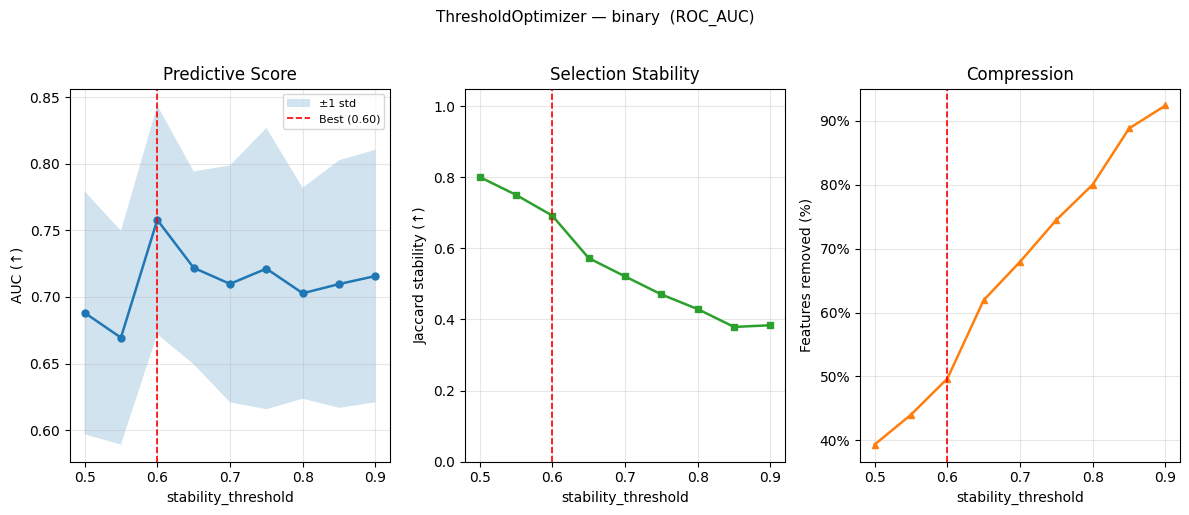

SECOM recommended threshold: 0.60
  Score      : 0.7579 +/- 0.0858
  Stability  : 0.692
  Compression: 49.6%  (297 of 590 features retained)


In [21]:
# Three-panel plot: score / stability / compression vs threshold
# Dashed red line marks the recommended threshold.
if res_secom is not None:
    fig = res_secom.plot(figsize=(12,5))
    if fig is not None:
        plt.tight_layout()
        plt.show()
    _best_secom = res_secom.best.threshold
    print(f'SECOM recommended threshold: {_best_secom:.2f}')
    print(f'  Score      : {res_secom.best.display_score:.4f} +/- {res_secom.best.std_score:.4f}')
    _ss = res_secom.best.stability
    print(f'  Stability  : {_ss:.3f}')
    print(f'  Compression: {res_secom.best.compression:.1%}  ({res_secom.best.mean_n_features:.0f} of {res_secom.best.total_features} features retained)')

---
## 4 · Benchmark 2: Urban Land Cover

| Property | Value |
|---|---|
| Dataset | Urban Land Cover (UCI) |
| Samples x features | 675 x 147 |
| Task | 9-class multiclass — urban land cover from aerial image segments |
| Algorithm | Random Forest (RF) |
| Score metric | AUC-OVR weighted (higher is better) |
| Challenges | Highly correlated spectral/texture descriptors; 9 imbalanced classes |
| Data access | Downloaded automatically from UCI on first run |

Classification is at the image-segment level (not pixel level), so there is no spatial
autocorrelation between rows.  The 147 features are highly correlated — many carry near-identical
information — so a higher threshold that enforces strict consistency should compress the feature
set without sacrificing much predictive signal.

In [23]:
# Urban Land Cover — downloaded as a ZIP from UCI; requires internet access.
# Random stratified 80/20 split.

URBAN_TASK = 'multiclass'

try:
    _url = 'https://archive.ics.uci.edu/static/public/295/urban+land+cover.zip'
    with urllib.request.urlopen(_url, timeout=30) as r:
        _data = r.read()

    _zf = zipfile.ZipFile(io.BytesIO(_data))
    _frames = []
    for _name in _zf.namelist():
        if _name.endswith('.csv') and not _name.startswith('__MACOSX'):
            with _zf.open(_name) as f:
                _df = pd.read_csv(f)
            if _df.shape[0] > 0:
                _frames.append(_df)

    if not _frames:
        raise ValueError('Urban Land Cover ZIP contained no usable CSV files.')

    _combined = pd.concat(_frames, ignore_index=True)
    y_raw = _combined['class'].astype(str).rename('land_cover').reset_index(drop=True)
    X_raw = (_combined.drop(columns=['class'])
                       .apply(pd.to_numeric, errors='coerce')
                       .reset_index(drop=True))

    X_urban, X_urban_test, y_urban, y_urban_test = train_test_split(
        X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw,
    )
    print(f'Urban loaded: {X_urban.shape[0]} train  x  {X_urban.shape[1]} features'
          f'  |  {X_urban_test.shape[0]} held-out test')
    print(f'  Task: {URBAN_TASK}  |  Split: random stratified 80/20 (random_state=42)')

except Exception as e:
    print(f'SKIP: Urban Land Cover unavailable — {e}')
    X_urban = y_urban = None

Urban loaded: 540 train  x  147 features  |  135 held-out test
  Task: multiclass  |  Split: random stratified 80/20 (random_state=42)


In [24]:
res_urban = None
if X_urban is None:
    print('Urban Land Cover not available — cell skipped.')
else:
    res_urban = ThresholdOptimizer(
        X_urban, y_urban,
        task_type   = URBAN_TASK,
        thresholds  = THRESHOLD_GRID,
        weights     = WEIGHTS,
        base_params = OPT_BASE,
        verbose     = True,
    ).run()
    res_urban.print_report()

  ThresholdOptimizer  —  9 threshold(s) to evaluate
  Grid                          [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
  Weights                       score=1  stability=1  compression=1
  Base CV                       outer_cv=10  inner_cv=5  n_bootstrap=25  n_iter=10

  [1/9]  threshold=0.50 … score=0.9824  stability=0.888  feats=74/147  (570s)
  [2/9]  threshold=0.55 … score=0.9817  stability=0.872  feats=71/147  (558s)
  [3/9]  threshold=0.60 … score=0.9801  stability=0.870  feats=70/147  (562s)
  [4/9]  threshold=0.65 … score=0.9821  stability=0.859  feats=64/147  (452s)
  [5/9]  threshold=0.70 … score=0.9830  stability=0.849  feats=61/147  (437s)
  [6/9]  threshold=0.75 … score=0.9818  stability=0.840  feats=58/147  (450s)
  [7/9]  threshold=0.80 … score=0.9832  stability=0.840  feats=55/147  (425s)
  [8/9]  threshold=0.85 … score=0.9819  stability=0.826  feats=48/147  (530s)
  [9/9]  threshold=0.90 … score=0.9815  stability=0.811  feats=44/147  (552s)

  Sweep com

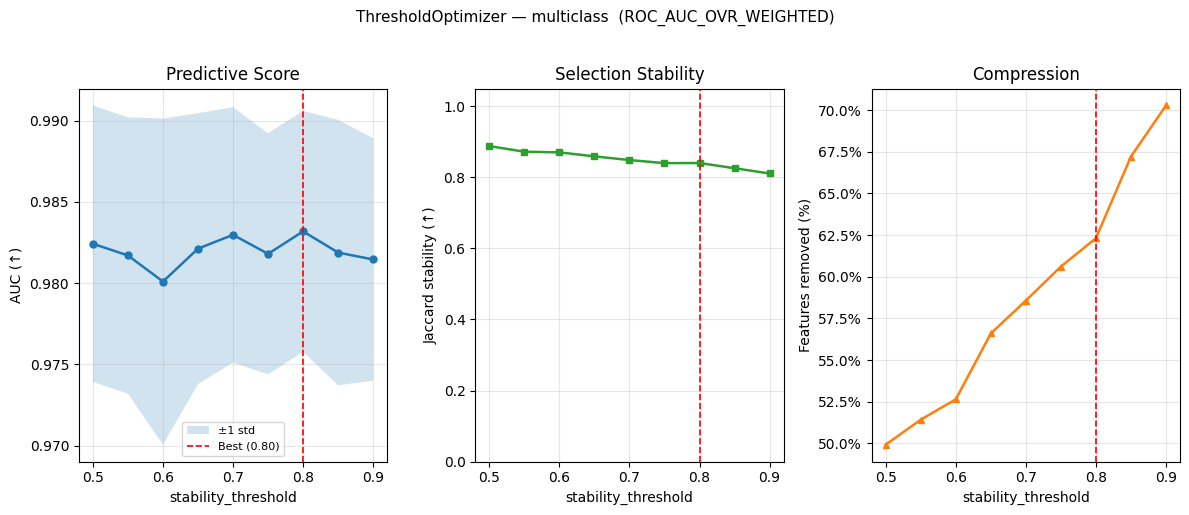

Urban recommended threshold: 0.80
  Score      : 0.9832 +/- 0.0074
  Stability  : 0.840
  Compression: 62.3%  (55 of 147 features retained)


In [25]:
if res_urban is not None:
    fig = res_urban.plot(figsize=(12,5))
    if fig is not None:
        plt.tight_layout()
        plt.show()
    _best_urban = res_urban.best.threshold
    print(f'Urban recommended threshold: {_best_urban:.2f}')
    print(f'  Score      : {res_urban.best.display_score:.4f} +/- {res_urban.best.std_score:.4f}')
    _ss = res_urban.best.stability
    print(f'  Stability  : {_ss:.3f}')
    print(f'  Compression: {res_urban.best.compression:.1%}  ({res_urban.best.mean_n_features:.0f} of {res_urban.best.total_features} features retained)')

---
## 5 · Dataset 3: Graphene Oxide Bulk

| Property | Value |
|---|---|
| Dataset | CSIRO Graphene Oxide Bulk |
| Samples x features | ~1 617 x ~309 (after NaN-column and constant-column removal) |
| Task | Regression — formation energy (eV) from MD structural descriptors |
| Algorithm | Random Forest (RF) |
| Score metric | RMSE in eV (lower is better; shown as positive RMSE in the report) |
| Challenges | High-dimensional correlated descriptor space; sparse features |
| Data access | **Local CSV required** — place `Graphene_Oxide_Bulk.csv` in `tools/` |

### Data access

This is a CSIRO dataset and is not downloaded automatically.  Place the CSV file in the
same `tools/` directory as this notebook:

```
RobustModelMaker/tools/Graphene_Oxide_Bulk.csv
```

More information: <https://doi.org/10.25919/5e30b45f9852c>

If the file is absent the cell prints `SKIP` and the dataset is excluded from the
cross-dataset summary.  SECOM and Urban Land Cover results are unaffected.

In [8]:
# Graphene Oxide Bulk — loaded from tools/Graphene_Oxide_Bulk.csv.
# Plain random 80/20 split — no stratification (regression target).

GRAPHENE_TASK = 'regression'
CSV_PATH      = TOOLS_DIR / 'Graphene_Oxide_Bulk.csv'
_MISS_THRESH  = 0.50  # drop columns with >50% missing values

if not CSV_PATH.exists():
    print(f'SKIP: Graphene_Oxide_Bulk.csv not found at {CSV_PATH}')
    print('Place it in the tools/ directory alongside this notebook.')
    print('Data record: https://doi.org/10.25919/5e30b45f9852c')
    X_graphene = y_graphene = None
else:
    df = pd.read_csv(CSV_PATH)

    # ── Drop metadata / non-feature columns ───────────────────────────────────
    NON_FEATURE = ['ID', 'file_name', 'Thermodynamic_Probability', 'Fermi_energy']
    TARGET_COL  = 'Formation_energy'
    drop_cols   = [c for c in NON_FEATURE if c in df.columns]
    y_raw = df[TARGET_COL].astype(float)
    X_raw = (df.drop(columns=drop_cols + [TARGET_COL])
               .apply(pd.to_numeric, errors='coerce'))

    # Drop rows where target is missing
    valid = y_raw.notna()
    X_raw = X_raw.loc[valid].reset_index(drop=True)
    y_raw = y_raw.loc[valid].reset_index(drop=True)

    # Drop columns with excessive missingness (> _MISS_THRESH)
    # Columns that are only partially NaN in the full dataset can become entirely
    # NaN within a CV training fold, causing RobustModelMaker to raise ValueError.
    _miss      = X_raw.isna().mean()
    _high_miss = (_miss > _MISS_THRESH).sum()
    X_raw      = X_raw.loc[:, _miss <= _MISS_THRESH]

    # Drop columns that are entirely NaN (belt-and-suspenders)
    X_raw = X_raw.dropna(axis=1, how='all')

    # Drop globally constant columns (zero variance after median fill)
    _medians = X_raw.median()
    _filled  = X_raw.fillna(_medians)
    _keep    = _filled.var() > 0
    _const   = (~_keep).sum()
    X_raw    = X_raw.loc[:, _keep]

    X_graphene, X_graphene_test, y_graphene, y_graphene_test = train_test_split(
        X_raw, y_raw, test_size=0.2, random_state=42,
    )
    print(f'Graphene loaded: {X_graphene.shape[0]} train  x  {X_graphene.shape[1]} features'
          f'  |  {X_graphene_test.shape[0]} held-out test')
    print(f'  Source : {CSV_PATH.name}  |  Task: {GRAPHENE_TASK}'
          f'  |  Split: random 80/20 (random_state=42)')
    print(f'  Dropped: {_high_miss} cols >{_MISS_THRESH:.0%} missing'
          f'  +  {_const} constant cols')

Graphene loaded: 1293 train  x  309 features  |  324 held-out test
  Source : Graphene_Oxide_Bulk.csv  |  Task: regression  |  Split: random 80/20 (random_state=42)
  Dropped: 48 cols >50% missing  +  105 constant cols


In [10]:
res_graphene = None
if X_graphene is None:
    print('Graphene Oxide dataset not available — cell skipped.')
else:
    res_graphene = ThresholdOptimizer(
        X_graphene, y_graphene,
        task_type   = GRAPHENE_TASK,
        thresholds  = THRESHOLD_GRID,
        weights     = WEIGHTS,
        base_params = OPT_BASE,
        verbose     = True,
    ).run()
    res_graphene.print_report()

  ThresholdOptimizer  —  9 threshold(s) to evaluate
  Grid                          [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
  Weights                       score=1  stability=1  compression=1
  Base CV                       outer_cv=10  inner_cv=5  n_bootstrap=25  n_iter=10

  [1/9]  threshold=0.50 … score=0.0458  stability=0.924  feats=154/309  (2722s)
  [2/9]  threshold=0.55 … score=0.0506  stability=0.919  feats=151/309  (2492s)
  [3/9]  threshold=0.60 … score=0.0443  stability=0.923  feats=149/309  (2559s)
  [4/9]  threshold=0.65 … score=0.0434  stability=0.925  feats=144/309  (2459s)
  [5/9]  threshold=0.70 … score=0.0484  stability=0.930  feats=141/309  (2424s)
  [6/9]  threshold=0.75 … score=0.0429  stability=0.935  feats=138/309  (2387s)
  [7/9]  threshold=0.80 … score=0.0455  stability=0.925  feats=135/309  (2533s)
  [8/9]  threshold=0.85 … score=0.0471  stability=0.922  feats=126/309  (2380s)
  [9/9]  threshold=0.90 … score=0.0501  stability=0.906  feats=122/309  (2

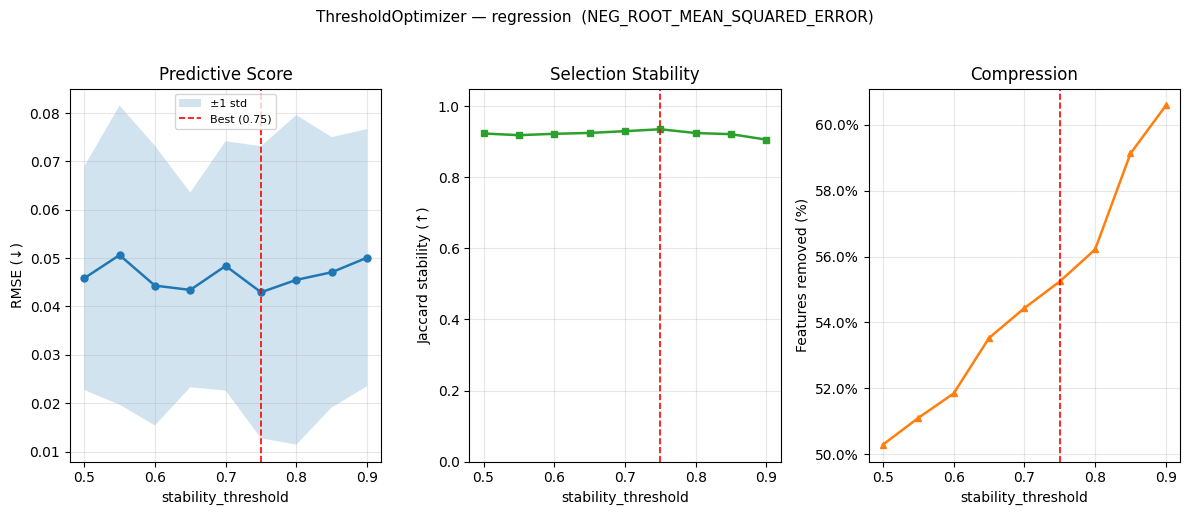

Graphene recommended threshold: 0.75
  Score (RMSE): 0.0429 +/- 0.0302
  Stability   : 0.935
  Compression : 55.2%  (138 of 309 features retained)


In [11]:
if res_graphene is not None:
    fig = res_graphene.plot(figsize=(12,5))
    if fig is not None:
        plt.tight_layout()
        plt.show()
    _best_graphene = res_graphene.best.threshold
    print(f'Graphene recommended threshold: {_best_graphene:.2f}')
    print(f'  Score (RMSE): {res_graphene.best.display_score:.4f} +/- {res_graphene.best.std_score:.4f}')
    _ss = res_graphene.best.stability
    print(f'  Stability   : {_ss:.3f}')
    print(f'  Compression : {res_graphene.best.compression:.1%}  ({res_graphene.best.mean_n_features:.0f} of {res_graphene.best.total_features} features retained)')

---
## 6 · Cross-dataset summary

The cells below collect the recommended threshold and associated metrics from each dataset
and present them in two formats:

1. **Summary table** — one row per dataset, showing the recommended threshold alongside all
   three objectives at that point.
2. **Overlay plot** — all three metric curves on the same axes, one colour per dataset, so
   you can see at a glance whether a single consensus threshold works across datasets or
   whether per-dataset tuning is warranted.

### Interpreting the results

If all three datasets return the same recommended threshold, that value is a strong candidate
for a single fixed setting in `ROBUST_PARAMS`.  If the recommendations diverge, examine the
Pareto fronts in each dataset's report above — there is often a threshold that is on the front
for every dataset, even if it is not the individual composite winner for each one.

In [27]:
import pandas as pd
import numpy as np
from collections import Counter

_pairs = [
    ('SECOM Manufacturing', res_secom),
    ('Urban Land Cover',    res_urban),
    ('Graphene Oxide Bulk', res_graphene),
]
available = [(label, res) for label, res in _pairs if res is not None]

if not available:
    print('No results yet — run the optimizer cells above first.')
else:
    rows = []
    for label, res in available:
        b     = res.best
        _stab = f'{b.stability:.3f}' if np.isfinite(b.stability) else 'n/a'
        rows.append({
            'Dataset':         label,
            'Rec. threshold':  b.threshold,
            'Score':           round(b.display_score, 4),
            'Stability':       _stab,
            'Compression':     f'{b.compression:.1%}',
            'Feats retained':  f'{b.mean_n_features:.0f} / {b.total_features}',
            'Composite':       round(b.composite, 3),
            'On Pareto front': not b.dominated,
        })

    df = pd.DataFrame(rows).set_index('Dataset')
    print('Recommended stability_threshold per dataset\n')
    print(df.to_string())
    print()

    _thresholds = [res.best.threshold for _, res in available]
    _consensus  = Counter(_thresholds).most_common(1)[0][0]
    print(f'Consensus threshold (most common recommendation): {_consensus:.2f}')
    print()
    print('To apply in your project:')
    print(f"    ROBUST_PARAMS['stability_threshold'] = {_consensus:.2f}")
    for label, res in available:
        _t   = res.best.threshold
        _tag = '  <- consensus' if _t == _consensus else ''
        print(f'  # {label}: recommended {_t:.2f}{_tag}')

Recommended stability_threshold per dataset

                     Rec. threshold   Score Stability Compression Feats retained  Composite  On Pareto front
Dataset                                                                                                     
SECOM Manufacturing            0.60  0.7579     0.692       49.6%      297 / 590      0.645             True
Urban Land Cover               0.80  0.9832     0.840       62.3%       55 / 147      0.664             True
Graphene Oxide Bulk            0.75  0.0429     0.935       55.2%      138 / 309      0.827             True

Consensus threshold (most common recommendation): 0.60

To apply in your project:
    ROBUST_PARAMS['stability_threshold'] = 0.60
  # SECOM Manufacturing: recommended 0.60  <- consensus
  # Urban Land Cover: recommended 0.80
  # Graphene Oxide Bulk: recommended 0.75


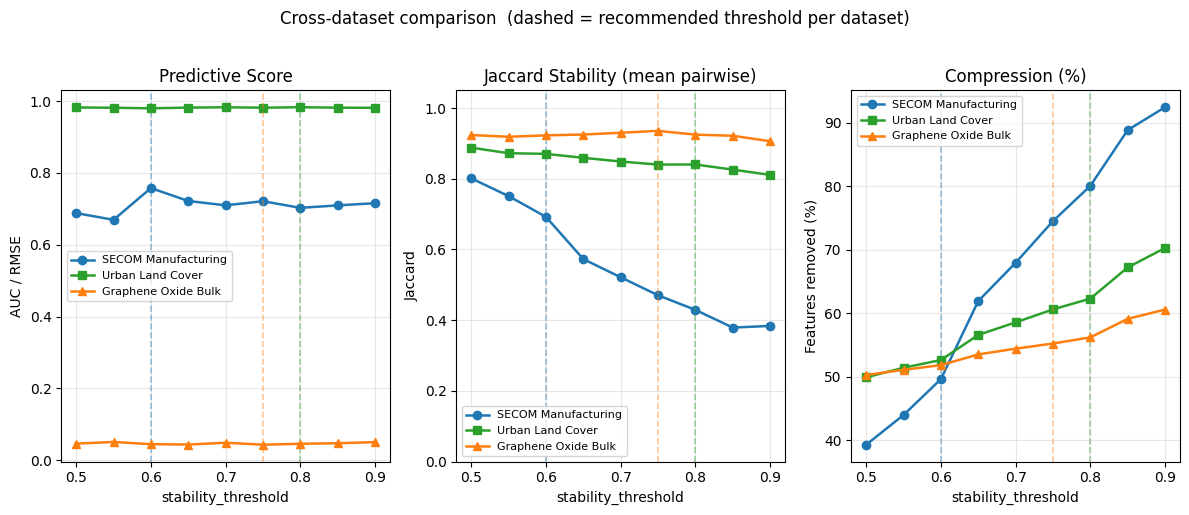

In [28]:
# Overlay plot: all datasets on the same three panels
if not available:
    print('No results to plot.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(12,5))
    colors  = ['tab:blue', 'tab:green', 'tab:orange']
    markers = ['o', 's', '^']

    for (label, res), color, marker in zip(available, colors, markers):
        _by_thr = sorted(res.results, key=lambda r: r.threshold)
        _thrs   = [r.threshold for r in _by_thr]
        _scores = [r.display_score for r in _by_thr]
        _stabs  = [r.stability if np.isfinite(r.stability) else np.nan
                   for r in _by_thr]
        _comprs = [r.compression * 100 for r in _by_thr]
        _best   = res.best.threshold

        axes[0].plot(_thrs, _scores, f'{marker}-', label=label, color=color,
                     linewidth=1.8, markersize=6)
        axes[0].axvline(_best, color=color, linestyle='--', alpha=0.45, linewidth=1.2)

        axes[1].plot(_thrs, _stabs, f'{marker}-', label=label, color=color,
                     linewidth=1.8, markersize=6)
        axes[1].axvline(_best, color=color, linestyle='--', alpha=0.45, linewidth=1.2)

        axes[2].plot(_thrs, _comprs, f'{marker}-', label=label, color=color,
                     linewidth=1.8, markersize=6)
        axes[2].axvline(_best, color=color, linestyle='--', alpha=0.45, linewidth=1.2)

    axes[0].set(title='Predictive Score', xlabel='stability_threshold',
                ylabel='AUC / RMSE')
    axes[1].set(title='Jaccard Stability (mean pairwise)', xlabel='stability_threshold',
                ylabel='Jaccard', ylim=(0, 1.05))
    axes[2].set(title='Compression (%)', xlabel='stability_threshold',
                ylabel='Features removed (%)')

    for ax in axes:
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        'Cross-dataset comparison  (dashed = recommended threshold per dataset)',
        y=1.02
    )
    plt.tight_layout()
    plt.show()

---
## 7 · Applying the results

### Option A — update your ROBUST_PARAMS dict

Copy the recommended threshold into your own parameter dictionary:

```python
ROBUST_PARAMS = dict(
    outer_cv            = 10,
    inner_cv            = 5,
    n_bootstrap         = 25,
    n_iter              = 10,
    stability_threshold = 0.75,   # <-- updated from optimizer
    cutoff_n_bootstrap  = 100,
    random_state        = 42,
    n_jobs              = 1,
    verbose             = False,
)
```

### Option B — use `best_params()` to merge directly

```python
ROBUST_PARAMS.update(res_secom.best_params())
# equivalent to: ROBUST_PARAMS['stability_threshold'] = res_secom.best.threshold
```

`best_params()` returns `{'stability_threshold': <value>}` ready to merge into any
parameter dictionary.

### Option C — per-dataset thresholds

If your datasets return substantially different recommendations, apply each individually:

```python
from RobustModelMaker import RobustModelMaker

params_secom = {**ROBUST_PARAMS, **res_secom.best_params()}
params_urban = {**ROBUST_PARAMS, **res_urban.best_params()}

rmm = RobustModelMaker(**params_secom)
rmm.fit(X_secom_train, y_secom_train)
```

---

### Reproducibility note

This notebook uses a **random 80/20 split** (`random_state=42`, stratified for classification)
rather than an adversarial worst-case split, so the recommended thresholds reflect typical
training conditions.  See the introduction for why this matters.

Re-running the full sweep (`QUICK_SCAN = False`) with the same `random_state`, scikit-learn
version, and RobustModelMaker version will reproduce the same results as this notebook.